In [7]:
import warnings
import matplotlib.pyplot as plt

from openap import top
import openap

warnings.filterwarnings("ignore")

## Full trajectory


### Original

In [8]:
actype = "A320"
origin = "EHAM"
destination = "LGAV"
m0 = 0.85

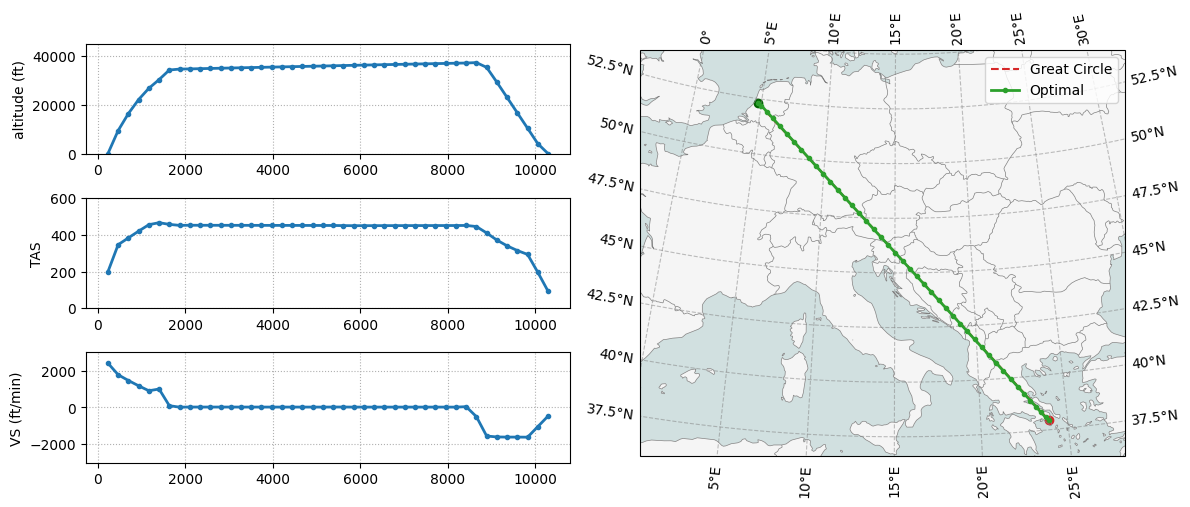

In [9]:
optimizer = top.CompleteFlight(actype, origin, destination, m0)
flight = optimizer.trajectory(objective="fuel")
top.vis.trajectory(flight)
plt.show()

### Adding waypoints

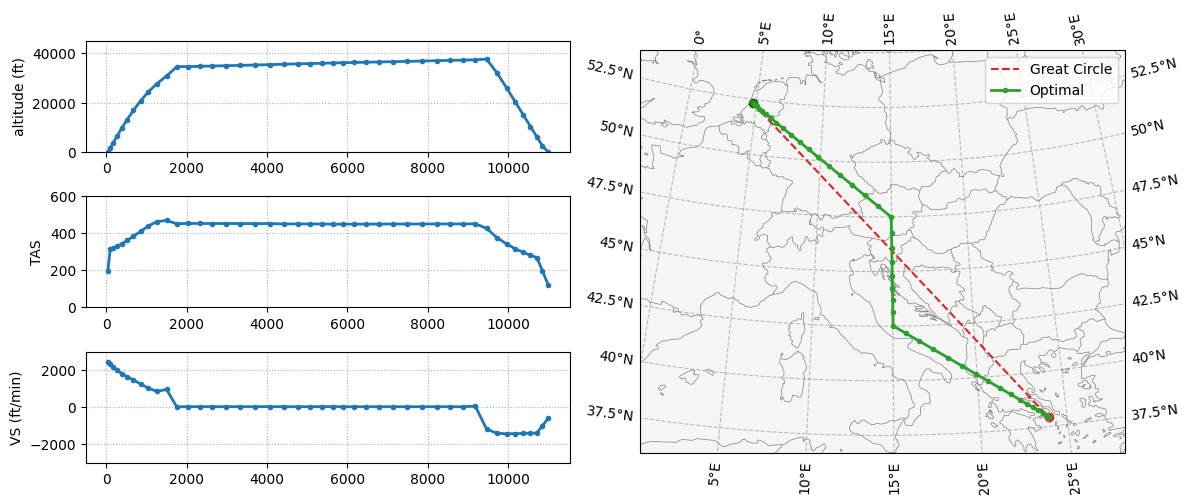

7884.177808372173


In [10]:
wps = [(42.5, 15), (47.5, 15)]
optimizer = top.CompleteFlight(actype, origin, destination, m0)
flight = optimizer.trajectory(objective="fuel", waypoints=wps)
top.vis.trajectory(flight)
plt.show()
print(flight.fuel_cost.sum())

### Non-uniform nodes spacing




##### For CompleteFlight() the nodes are forced to be more uniform by default, we can release this constraint.
##### When uniform_nodes=False, we get more nodes at lower altitudes

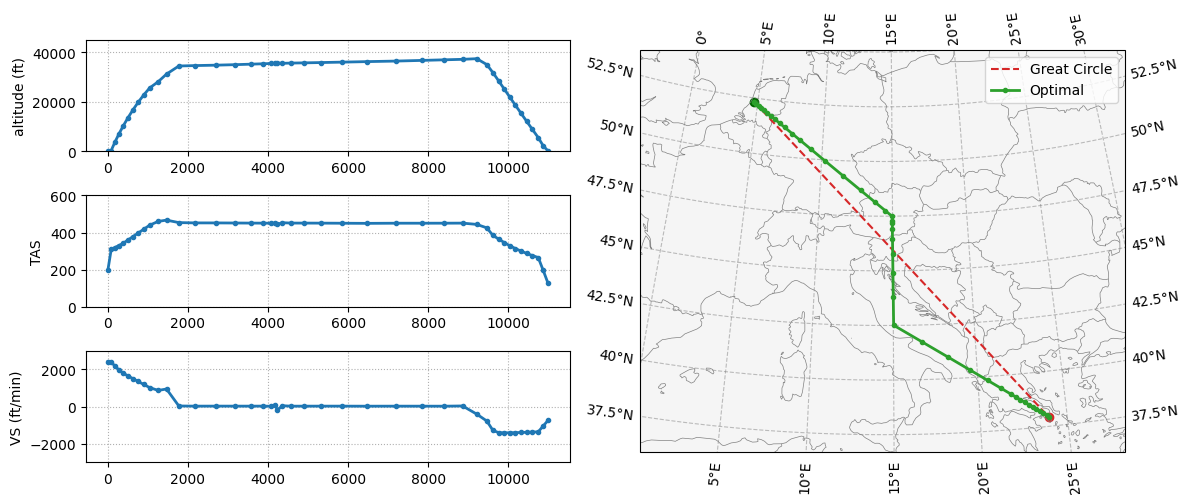

7858.521603394549


In [11]:
wps = [(42.5, 15), (47.5, 15)]
optimizer = top.CompleteFlight(actype, origin, destination, m0)
flight = optimizer.trajectory(objective="fuel", waypoints=wps, uniform_nodes=False)
top.vis.trajectory(flight)
plt.show()
print(flight.fuel_cost.sum())

## Examples with different phases



### Descent (by default uniform_nodes=False)

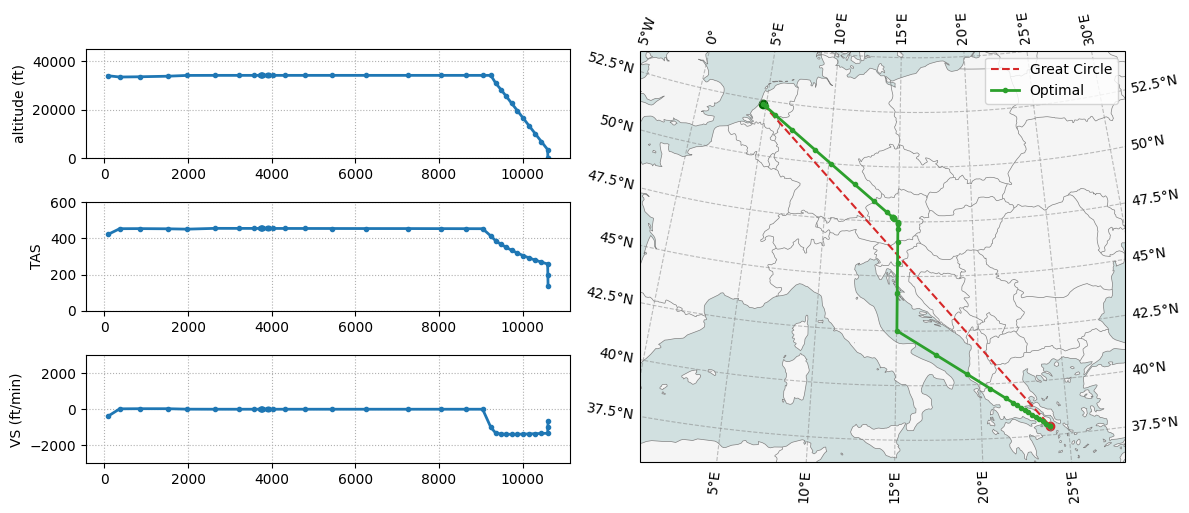

Fuel spent during descent phase only:  382.97365265476486


In [12]:
wps = [(42.5, 15), (47.5, 15)]
optimizer = top.Descent(actype, origin, destination, m0)
flight = optimizer.trajectory(objective="fuel", waypoints=wps, remove_cruise=False)

top.vis.trajectory(flight)
plt.show()
print(
    "Fuel spent during descent phase only: ",
    flight.query("vertical_rate<-600").fuel_cost.sum(),
)

##### Descent -  Uniform nodes

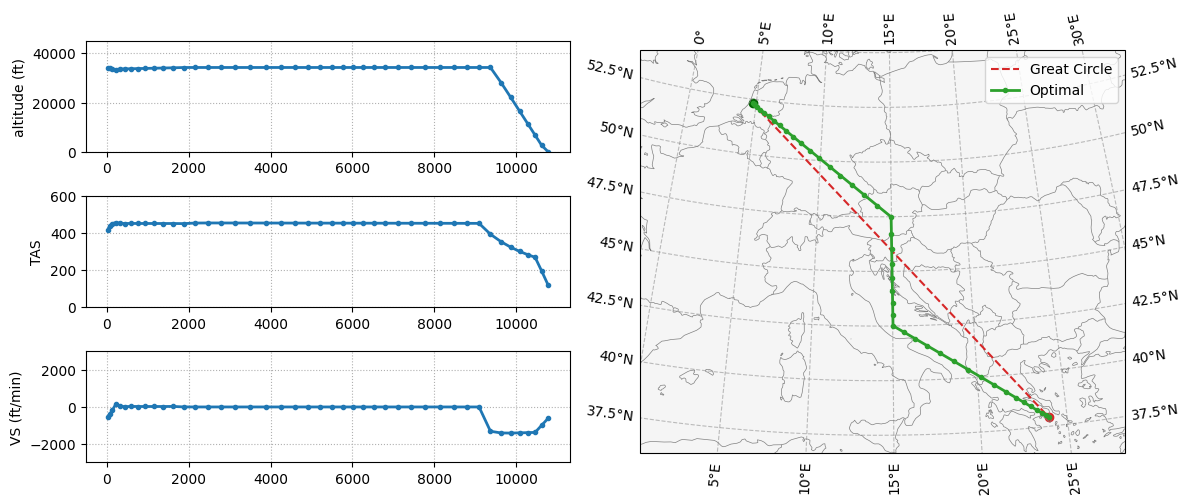

Fuel spent during descent phase only:  412.65535720186136


In [13]:
optimizer = top.Descent(actype, origin, destination, m0)
flight = optimizer.trajectory(
    objective="fuel", waypoints=wps, remove_cruise=False, uniform_nodes=True
)

top.vis.trajectory(flight)
plt.show()
print(
    "Fuel spent during descent phase only: ",
    flight.query("vertical_rate<-600").fuel_cost.sum(),
)

### Climb (by default: uniform_nodes= False)

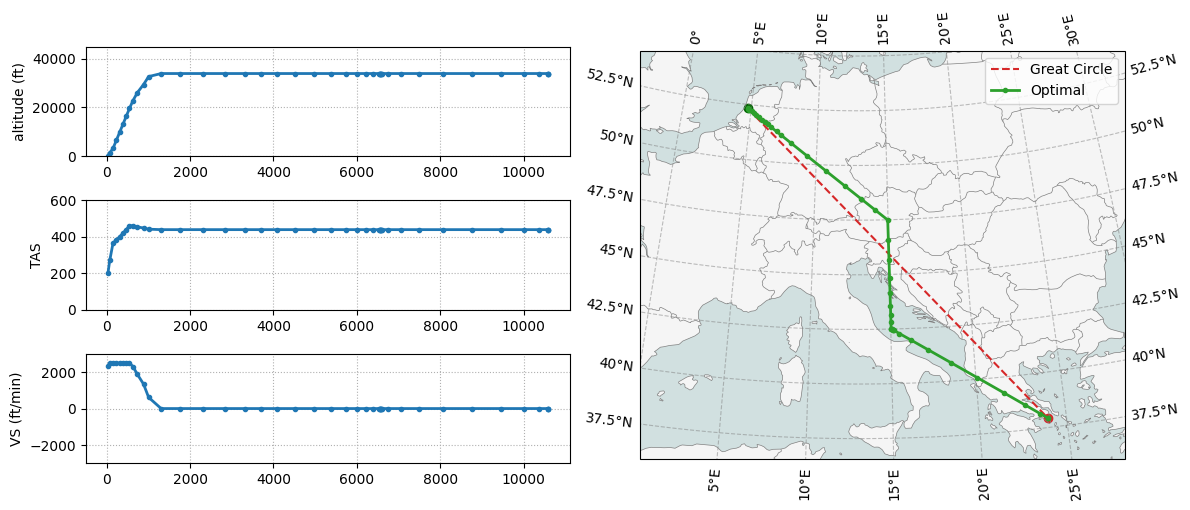

Fuel spent during climb phase only:  1450.426280857751


In [14]:
wps = [(42.5, 15), (47.5, 15)]
optimizer = top.Climb(actype, origin, destination, m0)
flight = optimizer.trajectory(objective="fuel", waypoints=wps, remove_cruise=False)

top.vis.trajectory(flight)
plt.show()
print(
    "Fuel spent during climb phase only: ",
    flight.query("vertical_rate>600").fuel_cost.sum(),
)

##### Climb - uniform nodes

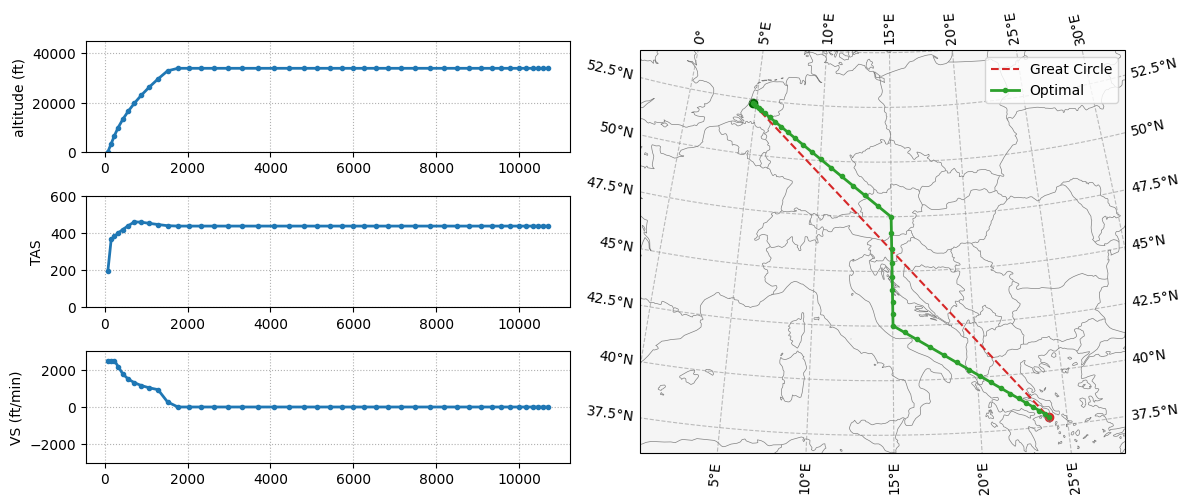

Fuel spent during climb phase only:  1734.7062767577568


In [15]:
optimizer = top.Climb(actype, origin, destination, m0)
flight = optimizer.trajectory(
    objective="fuel", waypoints=wps, remove_cruise=False, uniform_nodes=True
)

top.vis.trajectory(flight)
plt.show()
print(
    "Fuel spent during climb phase only: ",
    flight.query("vertical_rate>600").fuel_cost.sum(),
)

### Cruise (by default uniform_nodes=True)

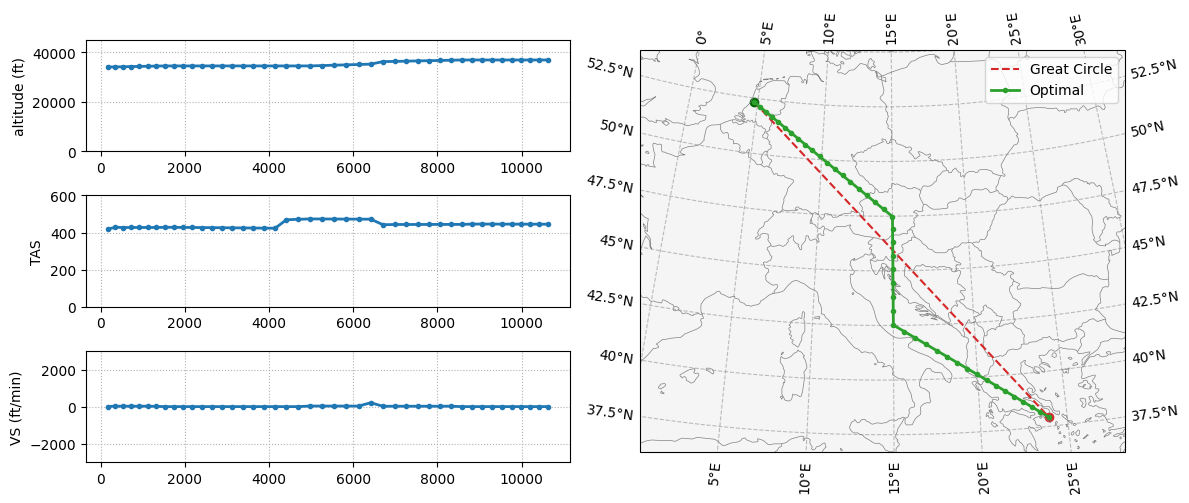

7684.609273126711


In [16]:
wps = [(42.5, 15), (47.5, 15)]
optimizer = top.Cruise(actype, origin, destination, m0)
flight = optimizer.trajectory(objective="fuel", waypoints=wps)

top.vis.trajectory(flight)
plt.show()
print(flight.fuel_cost.sum())

##### Cruise- non-uniform nodes


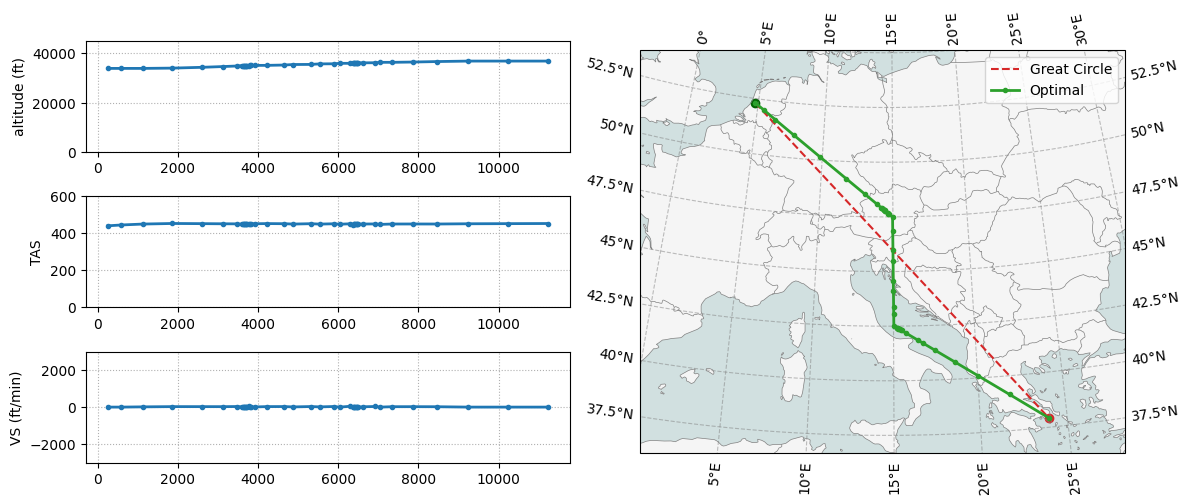

8150.631065682689


In [17]:
wps = [(42.5, 15), (47.5, 15)]
optimizer = top.Cruise(actype, origin, destination, m0)
flight = optimizer.trajectory(objective="fuel", waypoints=wps, uniform_nodes=False)

top.vis.trajectory(flight)
plt.show()
print(flight.fuel_cost.sum())